#**Lab 9: Privacy Preserving in Federated Learning**
In this lab, we will explore privacy preserving in the application of Federated Learning framework.
Federated Learning is a learning framework for multiple clients' Deep Learning models with their on-device
data to which you cannot have access. Instead of collecting all clients' data into one machine and training a
model, we bring the model to the data, train it locally, and merely upload "model updates" to a central server.
In this lab, we will achieve the following objectives.

# FedAvg Algorithm

**FedAvg (Federated Averaging)** is a fundamental algorithm in the field of **Federated Learning**. It allows multiple devices (clients) to collaboratively train a shared machine learning model without sharing their local data, thereby ensuring data privacy. Below is an overview of the algorithm:

## What is Federated Learning?
Federated learning is a distributed machine learning approach where training data is stored locally on devices (like smartphones, IoT devices, or edge servers) and not transferred to a central server. Instead of sending data, devices send updated model parameters after training on their local data.

## Overview of FedAvg Algorithm
**Federated Averaging (FedAvg)** was proposed in the paper _"Communication-Efficient Learning of Deep Networks from Decentralized Data"_ by H. Brendan McMahan et al. It combines **local Stochastic Gradient Descent (SGD)** on each client's device with a centralized aggregation of model updates. Here’s a step-by-step breakdown:

1. **Initialization**:
   - A central server initializes a global model with certain parameters $w_0$.

2. **Local Training**:
   - The server sends the global model $w_t$ to a subset of participating clients.
   - Each client receives the model, trains it on their local data using local SGD for a few epochs, and generates updated model parameters $w_{t+1}^k$, where $k$ is the client index.
   - This step respects the privacy of client data since data never leaves the client device.

3. **Aggregation**:
   - The server collects the updated model parameters $w_{t+1}^k$ from all participating clients.
   - It then averages the received parameters using a weighted average, where the weight for each client is typically proportional to the size of its local dataset:
     
     $w_{t+1} = \sum_{k=1}^K \frac{n_k}{n} w_{t+1}^k$
     
     where $n_k$ is the number of data points on client $k$ and $n$ is the total number of data points across all participating clients.

4. **Update and Repeat**:
   - The server updates the global model parameters with $w_{t+1}$ and repeats the process for a predetermined number of communication rounds or until convergence.



In [10]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [5]:

########################################################## Parameters ##########################################################

# number of clients
n_clients = 5

# number of global epochs
n_rounds = 5

# number of local epochs
local_epochs = 1

# batch size
batch_size = 32

# learning rate
lr = 0.01



########################################################## Data and Model Preperation ##########################################################


# get device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# preprocessor
transform = transforms.Compose([transforms.ToTensor()])

# load mnist data
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# data sizes
data_size = len(train_dataset)
indices = np.arange(data_size)
np.random.shuffle(indices)

# random split data for each client
split_sizes = np.random.dirichlet(np.ones(n_clients)) * data_size
split_sizes = split_sizes.astype(int)
split_sizes[-1] = data_size - np.sum(split_sizes[:-1])

# obtain local data indices
client_indices = []
start = 0
for size in split_sizes:
    client_indices.append(indices[start:start+size])
    start += size

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 200),
            nn.ReLU(),
            nn.Linear(200, 10)
        )

    def forward(self, x):
        return self.fc(x)
# setup global model
global_model = SimpleNN().to(device)

# setup client models
client_models = [SimpleNN().to(device) for _ in range(n_clients)]


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 15900806.38it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 478113.11it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 4410338.44it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 9150109.88it/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [11]:
#evaluate acc on test set
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


In [7]:
# record accs
global_accuracies = []
client_accuracies = [[] for _ in range(n_clients)]

# loss func
criterion = nn.CrossEntropyLoss()

for round_num in range(n_rounds):
    print(f"round {round_num+1}/{n_rounds}")

    # distribute global model to client model
    for client_model in client_models:
        client_model.load_state_dict(global_model.state_dict())

    local_weights = []

    # client training
    for idx, client_model in enumerate(client_models):
        client_data = Subset(train_dataset, client_indices[idx])
        train_loader = DataLoader(client_data, batch_size=batch_size, shuffle=True)
        optimizer = optim.SGD(client_model.parameters(), lr=lr)

        client_model.train()
        for epoch in range(local_epochs):
            for data, labels in train_loader:
                data, labels = data.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = client_model(data)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # save local weights
        local_weights.append(client_model.state_dict())

        # eval local weights
        client_acc = evaluate(client_model, test_loader)
        client_accuracies[idx].append(client_acc)
        print(f" client {idx+1} acc: {client_acc:.2f}%")

    # model aggregation（FedAvg）
    global_weights = global_model.state_dict()
    for key in global_weights.keys():
        global_weights[key] = torch.stack([local_weights[i][key] for i in range(n_clients)], 0).mean(0)
    global_model.load_state_dict(global_weights)

    # eval global model
    global_acc = evaluate(global_model, test_loader)
    global_accuracies.append(global_acc)
    print(f" eval global model: {global_acc:.2f}%\n")


round 1/5
 client 1 acc: 74.61%
 client 2 acc: 70.84%
 client 3 acc: 82.74%
 client 4 acc: 83.11%
 client 5 acc: 74.63%
 eval global model: 80.64%

round 2/5
 client 1 acc: 84.01%
 client 2 acc: 82.53%
 client 3 acc: 86.95%
 client 4 acc: 86.45%
 client 5 acc: 83.97%
 eval global model: 85.37%

round 3/5
 client 1 acc: 87.02%
 client 2 acc: 86.14%
 client 3 acc: 88.35%
 client 4 acc: 88.00%
 client 5 acc: 86.90%
 eval global model: 87.58%

round 4/5
 client 1 acc: 88.71%
 client 2 acc: 88.16%
 client 3 acc: 89.30%
 client 4 acc: 89.23%
 client 5 acc: 88.36%
 eval global model: 88.90%

round 5/5
 client 1 acc: 89.04%
 client 2 acc: 88.91%
 client 3 acc: 89.67%
 client 4 acc: 89.68%
 client 5 acc: 89.28%
 eval global model: 89.50%



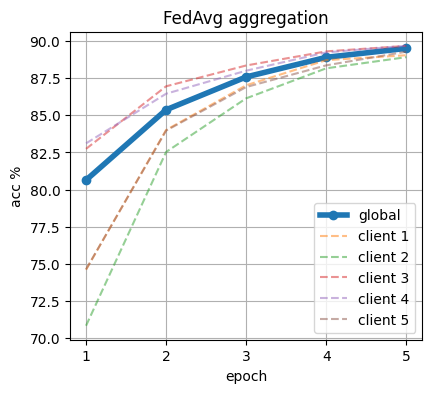

In [8]:
# Plot acc curves
plt.figure(figsize=(10, 4))
rounds = np.arange(1, n_rounds+1)

plt.subplot(1, 2, 1)
plt.plot(rounds, global_accuracies, label='global',  linewidth=4, marker='o')
for idx in range(n_clients):
    plt.plot(rounds, client_accuracies[idx], label=f'client {idx+1}', linestyle='--', alpha=0.5)
plt.xlabel('epoch')
plt.ylabel('acc %')
plt.title('FedAvg aggregation')
plt.legend()
plt.grid(True)

# FedAvg with Differential Privacy (FedAvg with DP)

**Federated Averaging with Differential Privacy (FedAvg with DP)** is an enhancement of the **FedAvg** algorithm, incorporating **Differential Privacy (DP)** to ensure stronger privacy guarantees for participants in the federated learning process. This approach is particularly important in scenarios where clients (such as smartphones, IoT devices, or hospitals) have sensitive data, and additional privacy measures are required to prevent information leakage through model updates.

## Key Concepts

1. **Differential Privacy (DP)**:
   - Differential Privacy is a mathematical framework that ensures that the inclusion or exclusion of a single data point in a dataset has a minimal impact on the output of a computation.
   - A mechanism is said to be $(\epsilon, \delta)$-differentially private if, for any two neighboring datasets (differing by a single record), the output distributions of the mechanism are similar, controlled by parameters $\epsilon$ (privacy loss) and $\delta$ (probability of failure).

2. **FedAvg**:
   - As introduced earlier, Federated Averaging (FedAvg) is a method where each client trains a model locally on their own data and then shares the model parameters (not the data itself) with a central server.
   - The central server aggregates these model updates (typically using weighted averaging) to update the global model.

## FedAvg with Differential Privacy

**FedAvg with DP** combines the privacy-preserving data locality of FedAvg with the formal privacy guarantees of DP. Here’s how it works:

1. **Local Training with DP**:
   - Each participating client performs local training on their private dataset using Stochastic Gradient Descent (SGD) or another optimization algorithm.
   - To ensure that updates do not leak information about any single training example, each client adds **random noise** to their local model updates. The noise is typically drawn from a **Gaussian** distribution.
   - This noise addition is designed to meet $(\epsilon, \delta)$-differential privacy criteria, ensuring that the updates do not reveal sensitive details about individual data points.

2. **Clipping Gradients**:
   - Before adding noise, clients apply **gradient clipping** to their updates to bound their sensitivity. This limits the influence of any single training sample on the model update, which is crucial for effective differential privacy.
   - Each client clips their model updates (gradients) using a threshold $C$:
     
     $\Delta w^k = \frac{\Delta w^k}{\max\left(1, \frac{\|\Delta w^k\|}{C}\right)}
     $
     where $\Delta w^k$ represents the model update of client $k$.

3. **Adding Noise for Differential Privacy**:
   - After clipping, each client adds noise to their updates before sending them to the server:
     $\tilde{\Delta w}^k = \Delta w^k + \mathcal{N}(0, \sigma^2 C^2)$
     where $\mathcal{N}(0, \sigma^2 C^2)$ represents Gaussian noise with variance $\sigma^2 C^2$.

4. **Aggregation**:
   - The central server collects the noisy updates \(\tilde{\Delta w}^k\) from participating clients.
   - It aggregates the updates using a weighted average (similar to standard FedAvg):
     $w_{t+1} = \sum_{k=1}^K \frac{n_k}{n} \tilde{\Delta w}^k$
     where \( n_k \) is the number of data points on client \( k \) and \( n \) is the total number of data points across all participating clients.

5. **Global Model Update**:
   - The global model is updated with the aggregated (and now differentially private) updates:
     $w_{t+1} = w_t + w_{t+1}$
   - This process is repeated for several communication rounds until the model converges or achieves satisfactory performance.



=== start exp：clip_norm=0.5, noise_multiplier=0.5 ===
Round 1: global acc: 56.27%
Round 2: global acc: 67.78%
Round 3: global acc: 75.56%
Round 4: global acc: 77.85%
Round 5: global acc: 80.28%

=== start exp：clip_norm=0.5, noise_multiplier=1.0 ===
Round 1: global acc: 50.24%
Round 2: global acc: 53.50%
Round 3: global acc: 60.97%
Round 4: global acc: 69.79%
Round 5: global acc: 74.13%

=== start exp：clip_norm=0.5, noise_multiplier=2.0 ===
Round 1: global acc: 20.28%
Round 2: global acc: 26.20%
Round 3: global acc: 30.82%
Round 4: global acc: 44.02%
Round 5: global acc: 52.17%

=== start exp：clip_norm=1.0, noise_multiplier=0.5 ===
Round 1: global acc: 57.74%
Round 2: global acc: 71.88%
Round 3: global acc: 78.24%
Round 4: global acc: 81.99%
Round 5: global acc: 83.68%

=== start exp：clip_norm=1.0, noise_multiplier=1.0 ===
Round 1: global acc: 35.42%
Round 2: global acc: 49.34%
Round 3: global acc: 62.03%
Round 4: global acc: 67.59%
Round 5: global acc: 69.09%

=== start exp：clip_norm=

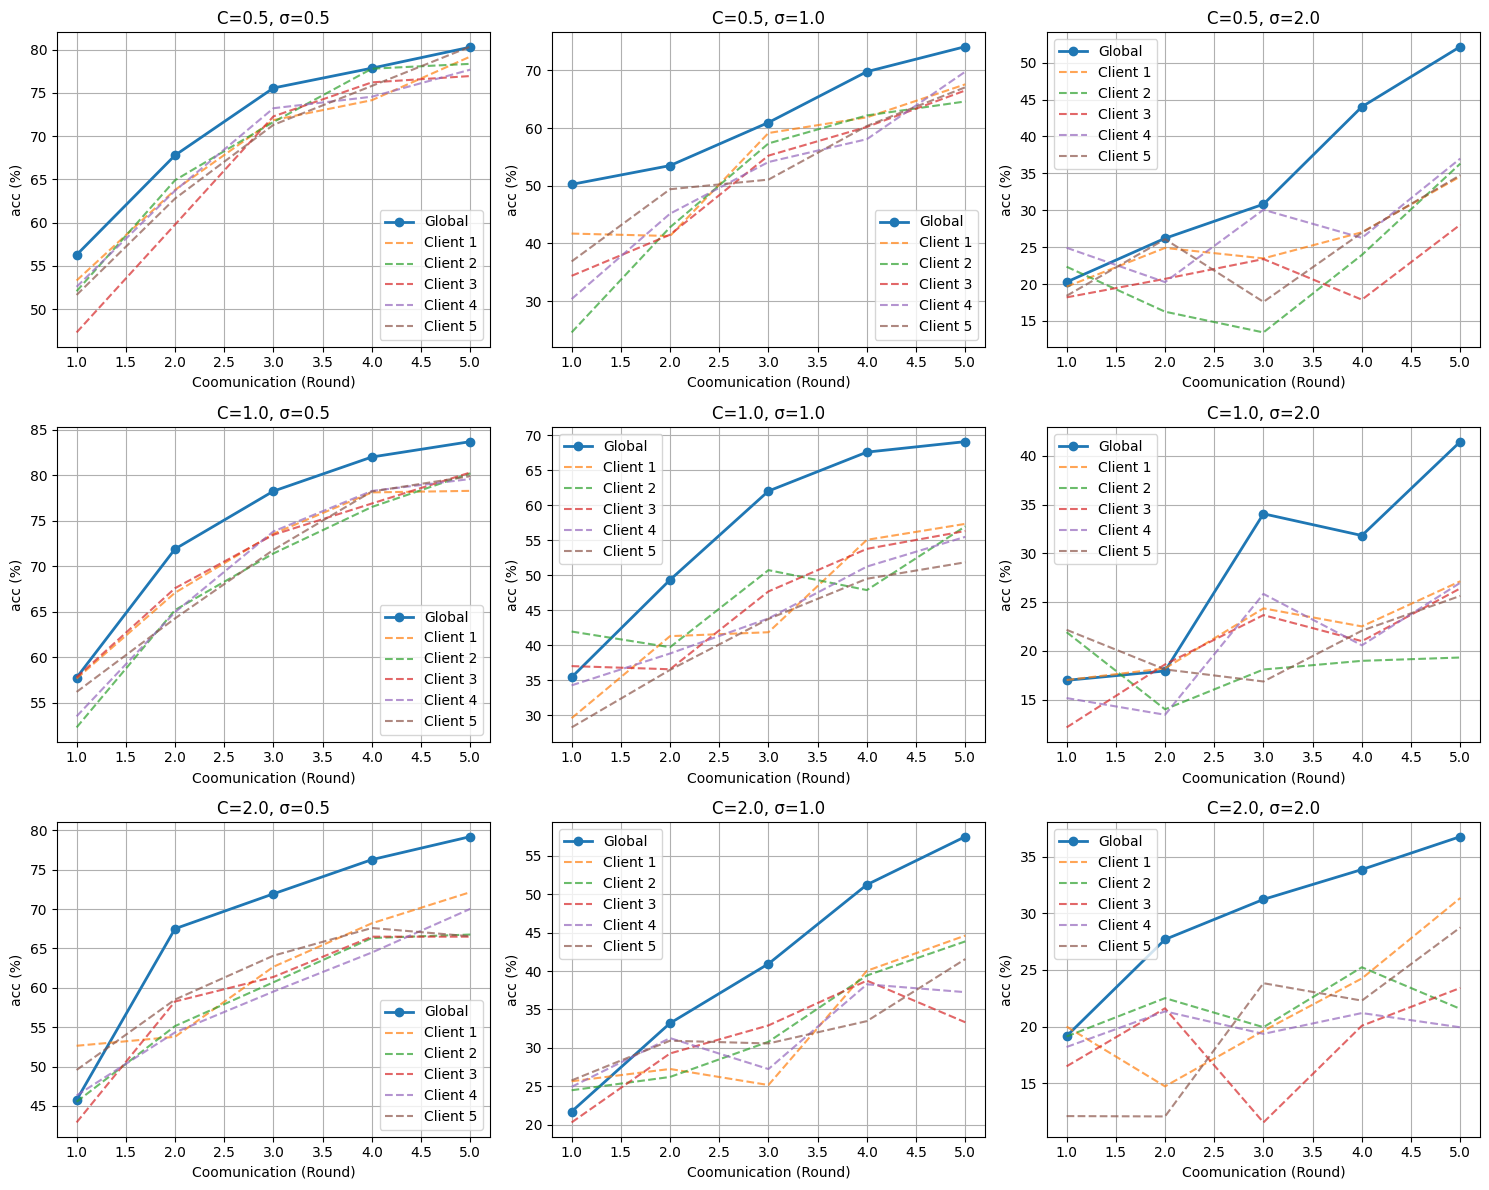

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

num_clients = 5  # number of clients
num_rounds = 5  # communication rounds
epochs_per_client = 1  # local training rounds
batch_size = 64  # local training batches
learning_rate = 0.01


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# define a model
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.layer1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        out = self.layer1(x)
        out = self.relu(out)
        out = self.layer2(out)
        return out

# load model
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# random partition data to each client
data_indices = np.arange(len(train_dataset))
np.random.shuffle(data_indices)
split_indices = np.array_split(data_indices, num_clients)

client_data_sizes = [len(indices) for indices in split_indices]
total_data_size = sum(client_data_sizes)

client_datasets = []
for indices in split_indices:
    subset = Subset(train_dataset, indices)
    client_datasets.append(subset)


def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss(reduction='sum')
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    avg_loss = total_loss / total
    return accuracy, avg_loss

# hyper parms
clip_norm_list = [0.5, 1.0, 2.0]  # gradient cliping norm
noise_multiplier_list = [0.5, 1.0, 2.0]  # dp noise σ

experiment_results = {}

# grid search
for clip_norm in clip_norm_list:
    for noise_multiplier in noise_multiplier_list:
        print(f"\n=== start exp：clip_norm={clip_norm}, noise_multiplier={noise_multiplier} ===")


        sigma = noise_multiplier
        C = clip_norm

        # init global model
        global_model = SimpleMLP().to(device)
        global_model.train()

        # store accs
        global_accuracies = []
        client_accuracies = [[] for _ in range(num_clients)]

        # global model training loops
        for round_num in range(num_rounds):
            # print(f"\n--- {round_num+1} th communication round ---")
            global_params = global_model.state_dict()
            aggregated_params = {}
            for key in global_params.keys():
                aggregated_params[key] = torch.zeros_like(global_params[key])

            # save client model
            client_models = []

            # client model training
            for client_idx, client_dataset in enumerate(client_datasets):
                local_model = SimpleMLP().to(device)
                local_model.load_state_dict(global_params)
                optimizer = optim.SGD(local_model.parameters(), lr=learning_rate)
                criterion = nn.CrossEntropyLoss()
                dataloader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)

                local_model.train()

                # ccumulate grad
                sum_grads = {name: torch.zeros_like(param.data) for name, param in local_model.named_parameters()}
                total_samples = 0

                for epoch in range(epochs_per_client):
                    for images, labels in dataloader:
                        images, labels = images.to(device), labels.to(device)
                        optimizer.zero_grad()
                        outputs = local_model(images)
                        loss = criterion(outputs, labels)
                        loss.backward()

                        # batch grads
                        batch_grads = []
                        for param in local_model.parameters():
                            if param.grad is not None:
                                batch_grads.append(param.grad.view(-1))
                        batch_grads = torch.cat(batch_grads)

                        # get grads
                        grad_norm = torch.norm(batch_grads)

                        # clip grads
                        clip_coef = min(1.0, C / (grad_norm + 1e-6))
                        batch_grads = batch_grads * clip_coef

                        # add noise
                        noise = torch.normal(0, sigma * C, size=batch_grads.shape).to(device)
                        batch_grads += noise

                        # update model param with noise gradient
                        offset = 0
                        for param in local_model.parameters():
                            if param.grad is not None:
                                param_length = param.numel()
                                param.grad.data = batch_grads[offset:offset+param_length].view_as(param)
                                offset += param_length

                        # update model
                        optimizer.step()


                        total_samples += images.size(0)


                client_models.append(local_model.state_dict())

                # param aggregation by fed avg
                weight = client_data_sizes[client_idx] / total_data_size
                for key in aggregated_params.keys():
                    aggregated_params[key] += local_model.state_dict()[key] * weight

            # update global model
            global_model.load_state_dict(aggregated_params)

            # eval global model
            global_acc, global_loss = evaluate(global_model, test_loader)
            global_accuracies.append(global_acc * 100)
            print(f"Round {round_num+1}: global acc: {global_acc*100:.2f}%")

            # eval client model
            for idx, client_state in enumerate(client_models):
                client_model = SimpleMLP().to(device)
                client_model.load_state_dict(client_state)
                client_acc, client_loss = evaluate(client_model, test_loader)
                client_accuracies[idx].append(client_acc * 100)
                # print(f"client {idx+1} acc: {client_acc*100:.2f}%")

        # save model
        key = f"C={clip_norm}, σ={noise_multiplier}"
        experiment_results[key] = {
            'global_accuracies': global_accuracies,
            'client_accuracies': client_accuracies
        }

# plot accs for each param settings
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

rounds = np.arange(1, num_rounds+1)

for idx, (key, results) in enumerate(experiment_results.items()):
    ax = axes[idx]
    global_accuracies = results['global_accuracies']
    client_accuracies = results['client_accuracies']
    ax.plot(rounds, global_accuracies, label='Global', linewidth=2, marker='o')
    for client_idx in range(num_clients):
        ax.plot(rounds, client_accuracies[client_idx], label=f'Client {client_idx+1}', linestyle='--', alpha=0.7)
    ax.set_title(f'{key}')
    ax.set_xlabel('Coomunication (Round)')
    ax.set_ylabel('acc (%)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In this lab, we use an easy demo to implement federated learning. We use pytroch to create virtual workers to collaboratively train a federated learning task.

In this lab, we have learnt:
1. Federated learning involves some workers to collaboratively train a machine learning task with their own data;
2. Use DPSGD in federated learning setting;